# 1, パッケージのダウンロード


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# データの前処理

In [ ]:
df=pd.read_csv("/content/bingo_data.csv")

In [ ]:
df1 = df.fillna(0)

In [ ]:
# 'mid'を除外し、分析用の特徴量を選択
features = ['clear_lines', 'clear_cells', 'water_ave', 'care_ave',
           'playtime_ave',  'gacha_ave', 'coin_ave']
X = df1[features]


In [ ]:
# データの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#クラスタリングの実行

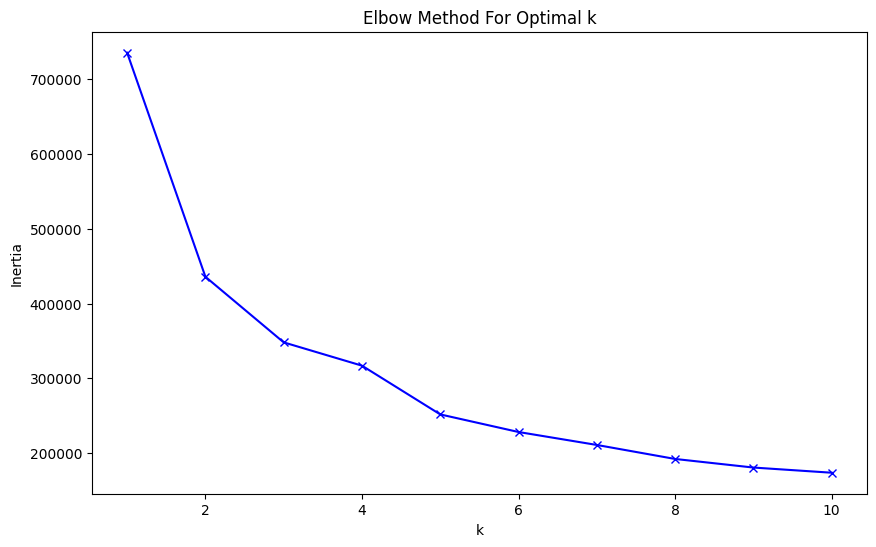

In [ ]:
# エルボー法でクラスター数を決定
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# エルボーカーブのプロット
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
# K-means クラスタリングの実行
n_clusters = 4  # エルボー法で決定したクラスター数
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 結果をデータフレームに追加
df['Cluster'] = clusters

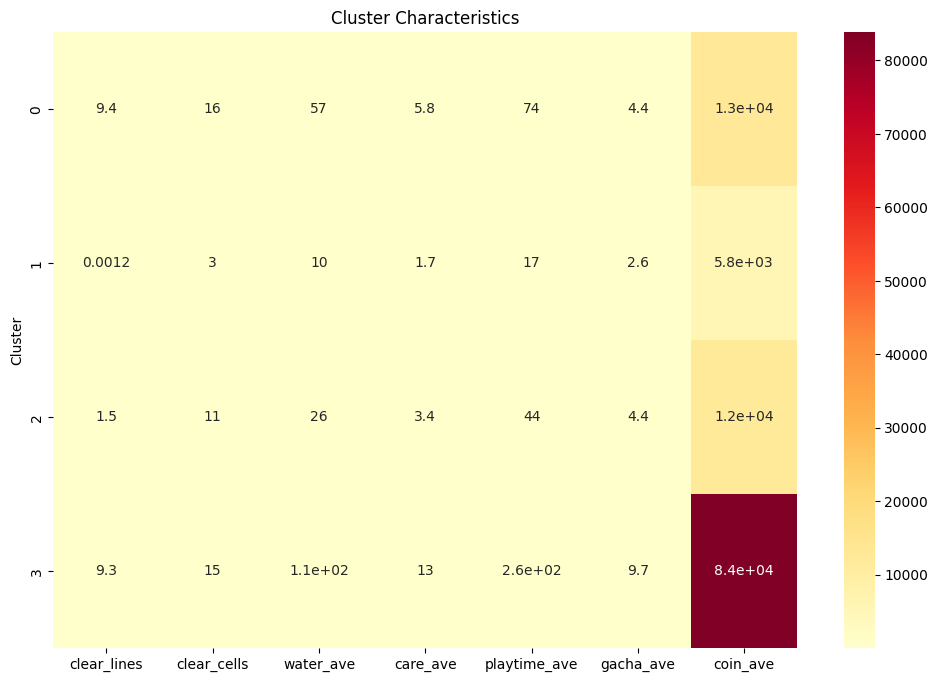


Cluster Sizes:
Cluster
1    40384
0    34118
2    23404
3     7143
Name: count, dtype: int64

Cluster Means:
         clear_lines  clear_cells   water_ave   care_ave  playtime_ave  \
Cluster                                                                  
0           9.426959    15.772232   56.845044   5.835978     73.786251   
1           0.001238     3.000173   10.070927   1.668596     16.851929   
2           1.521278    10.652410   26.188106   3.364953     43.598137   
3           9.254375    15.470951  112.698138  12.662453    257.124528   

         gacha_ave      coin_ave  
Cluster                           
0         4.381448  12691.483544  
1         2.593943   5763.517039  
2         4.379022  12360.825623  
3         9.690045  83860.186727  


In [ ]:
# クラスターごとの特徴量の平均値を計算
cluster_means = df.groupby('Cluster')[features].mean()

# ヒートマップで可視化
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means, cmap='YlOrRd', annot=True)
plt.title('Cluster Characteristics')
plt.show()

# クラスターごとの詳細な統計情報
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

print("\nCluster Means:")
print(cluster_means)

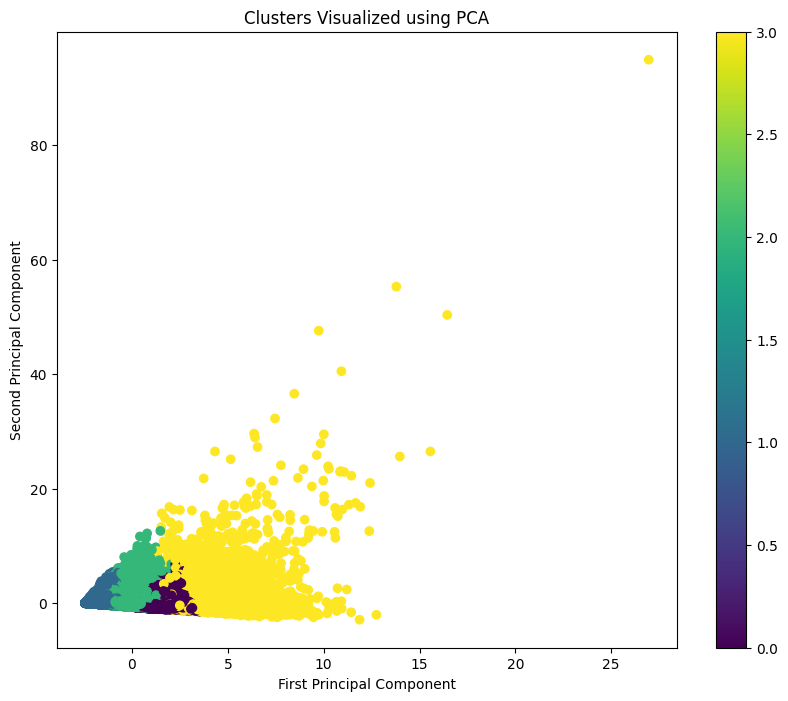

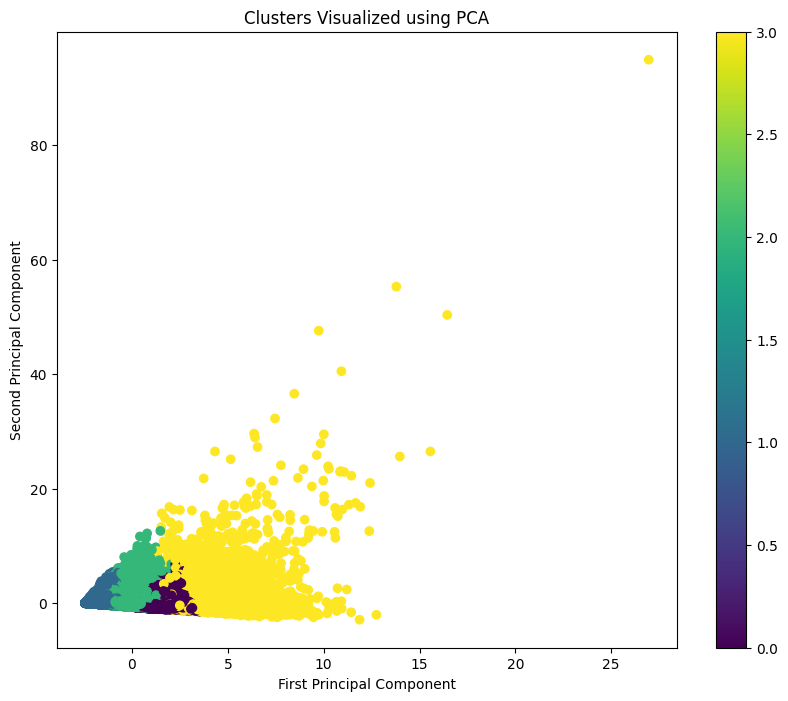

In [ ]:
# PCAで2次元に削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Clusters Visualized using PCA')
plt.colorbar(scatter)
plt.show()# PCAで2次元に削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Clusters Visualized using PCA')
plt.colorbar(scatter)
plt.show()

In [ ]:
# クラスターごとの特徴を解釈
for cluster in range(n_clusters):
    print(f"\nCluster {cluster} characteristics:")

    # このクラスターの中心値と全体の平均との差を計算
    cluster_center = cluster_means.iloc[cluster]
    overall_mean = df[features].mean()
    difference = cluster_center - overall_mean

    # 特徴的な変数を特定（平均との差が大きいもの）
    notable_features = difference.abs().sort_values(ascending=False)

    for feature in notable_features.index[:3]:  # 上位3つの特徴を表示
        if difference[feature] > 0:
            direction = "高い"
        else:
            direction = "低い"
        print(f"{feature}: 平均より{direction} ({difference[feature]:.2f})")


Cluster 0 characteristics:
coin_ave: 平均より低い (-7941.41)
water_ave: 平均より高い (20.54)
playtime_ave: 平均より高い (16.15)

Cluster 1 characteristics:
coin_ave: 平均より低い (-14869.38)
playtime_ave: 平均より低い (-40.79)
water_ave: 平均より低い (-26.24)

Cluster 2 characteristics:
coin_ave: 平均より低い (-8272.07)
playtime_ave: 平均より低い (-14.04)
water_ave: 平均より低い (-10.12)

Cluster 3 characteristics:
coin_ave: 平均より高い (63227.29)
playtime_ave: 平均より高い (199.48)
water_ave: 平均より高い (76.39)


#クラスタリングの評価

In [ ]:

# 3. 技術評価
def technical_evaluation(X, clusters):
    scores = {
        'シルエットスコア': silhouette_score(X, clusters),
        'Calinski-Harabasz指標': calinski_harabasz_score(X, clusters),
        'Davies-Bouldin指標': davies_bouldin_score(X, clusters)
    }
    print("\n技術評価指標:")
    for metric, score in scores.items():
        print(f"{metric}: {score:.3f}")
    return scores

In [ ]:
# 5. 評価実行
tech_scores = technical_evaluation(X_scaled, clusters)


技術評価指標:
シルエットスコア: 0.385
Calinski-Harabasz指標: 46215.876
Davies-Bouldin指標: 1.200


#k=3

In [ ]:
# K-means クラスタリングの実行
n_clusters = 3  # エルボー法で決定したクラスター数
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 結果をデータフレームに追加
df['Cluster'] = clusters

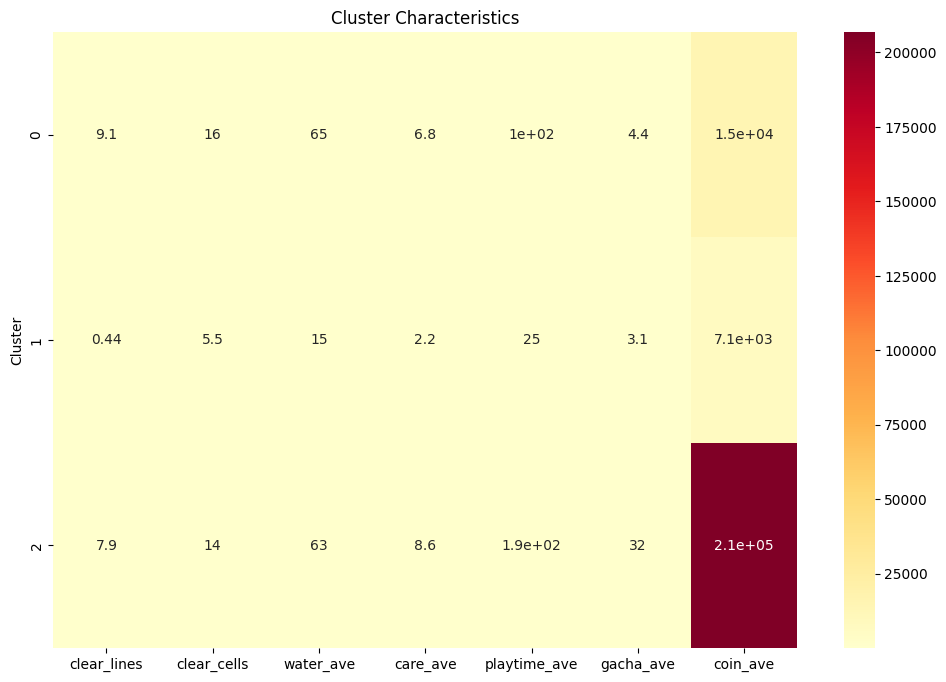


Cluster Sizes:
Cluster
1    61223
0    42203
2     1623
Name: count, dtype: int64

Cluster Means:
         clear_lines  clear_cells  water_ave  care_ave  playtime_ave  \
Cluster                                                                
0           9.085184    15.572779  65.027515  6.816375    100.513795   
1           0.444506     5.532888  15.147358  2.204787     24.603037   
2           7.856439    14.255083  62.847424  8.635212    188.893745   

         gacha_ave       coin_ave  
Cluster                            
0         4.414255   14650.035326  
1         3.102394    7088.608843  
2        32.337380  206808.124200  


In [ ]:
# クラスターごとの特徴量の平均値を計算
cluster_means = df.groupby('Cluster')[features].mean()

# ヒートマップで可視化
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means, cmap='YlOrRd', annot=True)
plt.title('Cluster Characteristics')
plt.show()

# クラスターごとの詳細な統計情報
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

print("\nCluster Means:")
print(cluster_means)

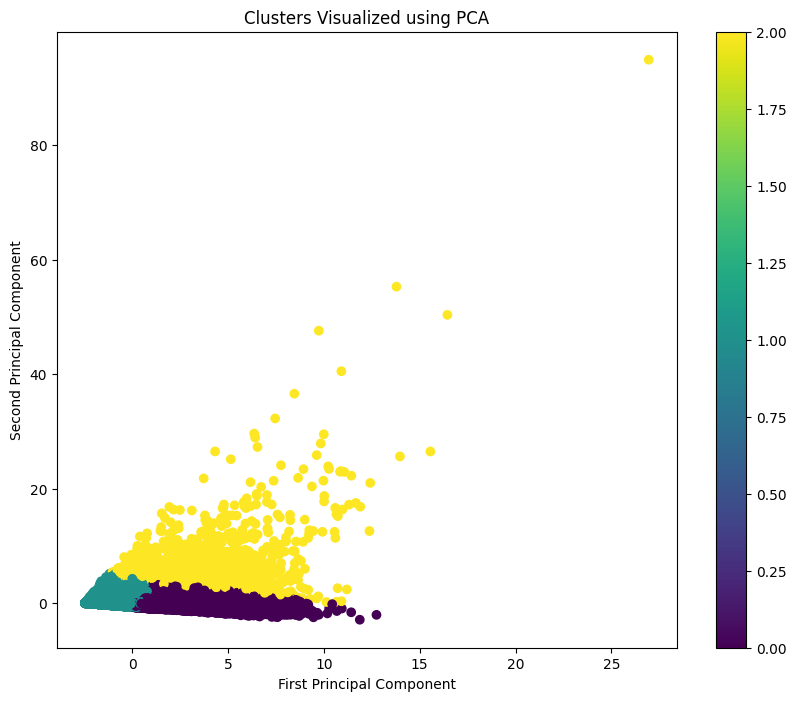

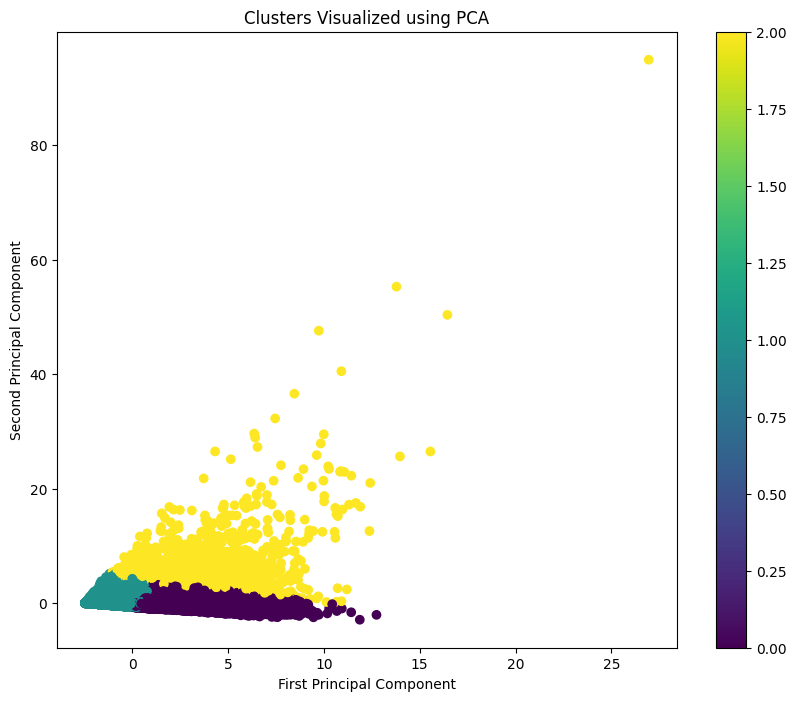

In [ ]:
# PCAで2次元に削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Clusters Visualized using PCA')
plt.colorbar(scatter)
plt.show()# PCAで2次元に削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Clusters Visualized using PCA')
plt.colorbar(scatter)
plt.show()

In [ ]:
# クラスターごとの特徴を解釈
for cluster in range(n_clusters):
    print(f"\nCluster {cluster} characteristics:")

    # このクラスターの中心値と全体の平均との差を計算
    cluster_center = cluster_means.iloc[cluster]
    overall_mean = df[features].mean()
    difference = cluster_center - overall_mean

    # 特徴的な変数を特定（平均との差が大きいもの）
    notable_features = difference.abs().sort_values(ascending=False)

    for feature in notable_features.index[:3]:  # 上位3つの特徴を表示
        if difference[feature] > 0:
            direction = "高い"
        else:
            direction = "低い"
        print(f"{feature}: 平均より{direction} ({difference[feature]:.2f})")


Cluster 0 characteristics:
coin_ave: 平均より低い (-5982.86)
playtime_ave: 平均より高い (42.88)
water_ave: 平均より高い (28.72)

Cluster 1 characteristics:
coin_ave: 平均より低い (-13544.28)
playtime_ave: 平均より低い (-33.04)
water_ave: 平均より低い (-21.16)

Cluster 2 characteristics:
coin_ave: 平均より高い (186175.23)
playtime_ave: 平均より高い (131.26)
gacha_ave: 平均より高い (28.13)


In [ ]:

# 3. 技術評価
def technical_evaluation(X, clusters):
    scores = {
        'シルエットスコア': silhouette_score(X, clusters),
        'Calinski-Harabasz指標': calinski_harabasz_score(X, clusters),
        'Davies-Bouldin指標': davies_bouldin_score(X, clusters)
    }
    print("\n技術評価指標:")
    for metric, score in scores.items():
        print(f"{metric}: {score:.3f}")
    return scores

In [ ]:
tech_scores = technical_evaluation(X_scaled, clusters)


技術評価指標:
シルエットスコア: 0.510
Calinski-Harabasz指標: 54966.230
Davies-Bouldin指標: 0.974
